© [Mariia Seleznova](https://www.ai.math.uni-muenchen.de/members/postdocs/mariia-seleznova/index.html), 2026. [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

# 🛠️ Linear Classification Setup

In this lecture, we set up some of the basic tools that we will use for our first machine learning setting, namely **linear binary classification**, where the goal is to classify each data sample into one of two classes.

We will test these tools on the **Iris dataset**, which you already know from the first lecture. The main goal of this lecture is to prepare the workflow and notation that we will build on in the next classes.

We begin by importing the required packages:

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

## 📥 Load the Data

Next, we load the Iris dataset from the UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/iris

Note that the column names are not included in the CSV file itself. They are described in the accompanying file: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.names

📌 Since the Iris dataset has become something like the machine learning equivalent of “Hello, World!”, it is also included in many ML libraries. For example, it is available in the `datasets` module of `scikit-learn`.

📌 Loading and preprocessing data is often one of the most tedious parts of machine learning workflows, because public datasets come in many different formats. For this reason, high-level ML frameworks (especially deep learning frameworks) often provide ready-to-use dataset modules for common benchmark datasets, which makes it easier to implement and test ML methods quickly.

In [2]:
file_name = 'iris_data_set.csv'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
column_names = ['sepal length [cm]', 'sepal width [cm]',
                'petal length [cm]', 'petal width [cm]', 'iris type']

if os.path.exists(file_name):
    print(f'Loading data from local file `{file_name}`...')
    df = pd.read_csv(file_name)
else:
    print(f'Loading data from `{url}`...')
    df = pd.read_csv(url, names=column_names)
    df.to_csv(file_name)
    print('Done.')

Loading data from local file `iris_data_set.csv`...


Let us inspect the data:

In [3]:
df

,Unnamed: 0,sepal length [cm],sepal width [cm],petal length [cm],petal width [cm],iris type
0,0,5.1,3.5,1.4,0.2,Iris-setosa
1,1,4.9,3.0,1.4,0.2,Iris-setosa
2,2,4.7,3.2,1.3,0.2,Iris-setosa
3,3,4.6,3.1,1.5,0.2,Iris-setosa
4,4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,145,6.7,3.0,5.2,2.3,Iris-virginica
146,146,6.3,2.5,5.0,1.9,Iris-virginica
147,147,6.5,3.0,5.2,2.0,Iris-virginica
148,148,6.2,3.4,5.4,2.3,Iris-virginica


## 🏷️ Assign Class Labels

The Iris dataset originally contains three classes. Since we consider **binary classification** in this lecture, we merge two of these classes into one.

We assign the label $-1$ to *Iris-setosa*, while *Iris-versicolor* and *Iris-virginica* are grouped together and assigned the label $+1$:

In [4]:
df["class"] = df["iris type"].map({
    "Iris-setosa": -1,
    "Iris-versicolor": 1,
    "Iris-virginica": 1
})

## ✂️ Train-Test Splits

In machine learning, we usually split the data into **training** and **test sets** in order to evaluate how well a model generalizes to new, unseen data.

- The **training set** is used to **fit** the model, that is, to learn patterns from the data.
- The **test set** is kept separate and used only for **evaluation**, to check how well the model performs on data it has not seen before.

This helps prevent **overfitting**, where a model fits the training data very well but fails to perform on new data. By comparing performance on the training and test sets, we can get a sense of whether the model is learning meaningful patterns rather than simply memorizing the data.

📌 Some workflows also include a **validation set**, which is used to tune hyperparameters but not to fit the model directly. We will not need this for now.

We define a custom function to perform a random train-test split:

In [5]:
def  train_test_split(df, training_data_fraction, shuffle=True):
    """
    Split all available data into a training and test data set.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame of available data.

    training_data_fraction : float
        The fraction of the data that should be used for training.
        E.g., `training_data_fraction=0.6` means 60%.

    shuffle : bool , optional
        If True, randomly reshuffles the data before the split.

    Returns:
    -------
    _df : DataFrame
        Shuffled DataFrame

    train_df: DataFrame
        Train split
        
    test_df: DataFrame
        Test split
    """
    
    if shuffle is True:
        _df = df.sample(frac=1).reset_index(drop=True)
    else:
        _df= df
    
    train_df = _df.iloc[:round(training_data_fraction*len(_df)),:]
    test_df = _df.iloc[round(training_data_fraction*len(_df)):,:]
    
    return _df, train_df, test_df

We can use this function as follows:

In [6]:
training_data_fraction = .8

df, train_df, test_df = train_test_split(df, training_data_fraction)

# convert DataFrame entries to Numpy arrays
# `X, Y`: all data
# `train_X, train_Y`: training data
# `test_X, test_Y`: training data

X = df[['sepal length [cm]', 'petal width [cm]']].to_numpy()
Y = df['class'].to_numpy()

train_X = train_df[['sepal length [cm]', 'petal width [cm]']].to_numpy()
train_Y = train_df['class'].to_numpy()

test_X = test_df[['sepal length [cm]', 'petal width [cm]']].to_numpy()
test_Y = test_df['class'].to_numpy()

print('Data split as follows:')
print(f'  Training data samples: {len(train_df)}')
print(f'      Test data samples: {len(test_df)}')

Data split as follows:
  Training data samples: 120
      Test data samples: 30


### 📌 Sidenote: Documentation

Our `train_test_split` function also includes ✨documentation✨.

Including documentation in your code is a **good practice**, especially if someone else (or your future self) might need to use it later.

Getting comfortable with **writing** and **reading documentation** is an essential part of learning to code.

In [7]:
?train_test_split

Signature: train_test_split(df, training_data_fraction, shuffle=True)
Docstring:
Split all available data into a training and test data set.

Parameters:
-----------
df : DataFrame
    DataFrame of available data.

training_data_fraction : float
    The fraction of the data that should be used for training.
    E.g., `training_data_fraction=0.6` means 60%.

shuffle : bool , optional
    If True, randomly reshuffles the data before the split.

Returns:
-------
_df : DataFrame
    Shuffled DataFrame

train_df: DataFrame
    Train split
    
test_df: DataFrame
    Test split
File:      c:\users\leon lorenz\appdata\local\temp\ipykernel_24764\2708045572.py
Type:      function

This documentation was generated directly from the *docstring* that we included right after the function name. Under the hood, the docstring gets saved as the function's `__doc__` argument:

In [8]:
train_test_split.__doc__

'\n    Split all available data into a training and test data set.\n    \n    Parameters:\n    -----------\n    df : DataFrame\n        DataFrame of available data.\n\n    training_data_fraction : float\n        The fraction of the data that should be used for training.\n        E.g., `training_data_fraction=0.6` means 60%.\n\n    shuffle : bool , optional\n        If True, randomly reshuffles the data before the split.\n\n    Returns:\n    -------\n    _df : DataFrame\n        Shuffled DataFrame\n\n    train_df: DataFrame\n        Train split\n        \n    test_df: DataFrame\n        Test split\n    '

💡 Docstrings usually follow this format:

- Short summary of the function
- Description of parameters
- Description of return values

## 🔍 Visualize the Training Data

For now, we will work with two-dimensional data so that we can visualize each step easily and develop some intuition for the basic ML concepts.

Of course, real datasets are often high-dimensional, and we will start working with such data very soon, starting from this week’s homework.

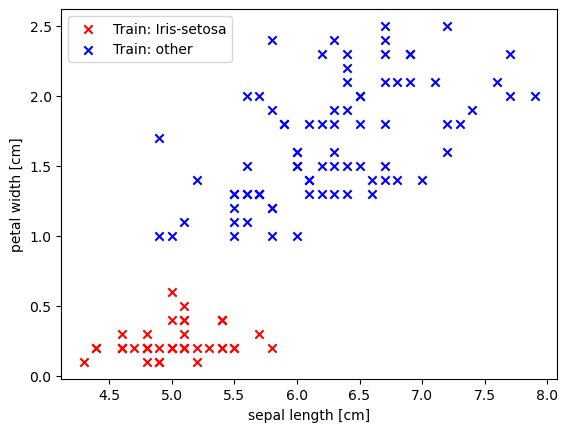

In [9]:
fig, ax = plt.subplots()

train_X_minus1 = train_X[train_Y == -1]
plt.scatter(train_X_minus1[:, 0], train_X_minus1[:, 1], marker='x', color='red', label='Train: Iris-setosa')

train_X_plus1 = train_X[train_Y == +1]
plt.scatter(train_X_plus1[:, 0], train_X_plus1[:, 1], marker='x', color='blue', label='Train: other')

plt.xlabel('sepal length [cm]')
plt.ylabel('petal width [cm]')
plt.legend()

## 🧱 Define a Class for Linear Binary Classification

Many high-level ML frameworks, including `scikit-learn`, implement models as Python **classes**. This follows the [object-oriented programming (OOP) paradigm](https://en.wikipedia.org/wiki/Object-oriented_programming). While this is not the only way to structure machine learning code, we will also follow the OOP approach in this course. It helps keep code modular, reusable, and easier to organize as projects become more complex.

🔔 Are you comfortable with OOP and Python classes? Or should we cover this in more detail?

Our class `LinearBinaryClassification` will represent the following decision function (or *hypothesis*):

$$
h_{w,b}(x)=\operatorname{sign}(w \cdot x + b),
$$

and will store the parameters $(w,b)$ as **class attributes**.

In [10]:
class LinearBinaryClassification:
    """
    Linear binary classification class.

    Stores a linear classification model with parameters (w,b)
    and decision function h(x) = sign(w @ x + b)

    Parameters:
    ----------
    w: array
    b: array

    """
    def __init__(self, w, b):
        self.w = w
        self.b = b
        
    def __call__(self, x):
        # Numpy's `where` function provides a fast substitution
        return np.where(x @ self.w + self.b >= 0.0, 1, -1)

For now, the class has only two *methods*:

- `__init__`: sets up the model with weights `w` and bias `b`. This method is called automatically when you create an instance of the class.
- `__call__`: lets you apply the model to new inputs using the syntax `model(x)`.

We can use this class as follows:

In [11]:
w = np.array([0.2, 1])
b = -1.8
model = LinearBinaryClassification(w, b)

x = np.array([4, 5])

print(f'For weight row vector w={w}, bias term b={b}, and argument vector x={x},\n'
      f'the model output is {model(x)}.')

For weight row vector w=[0.2 1. ], bias term b=-1.8, and argument vector x=[4 5],
the model output is 1.


## 🗺️ Visualize Decision Regions

For now, we choose the parameters manually and visualize the **decision regions** of the model, that is, the parts of the input space that are classified as $+1$ and $-1$.

In [12]:
w = np.array([-1, 3])
b = 1
model = LinearBinaryClassification(w, b)

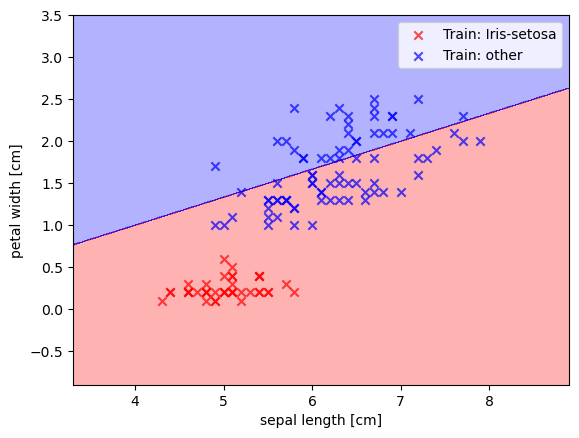

In [13]:
fig, ax = plt.subplots()

# compute how large the mesh for the contour plot shall be (with +/- 1 as
# safety bleed)
x1_min = train_X[:, 0].min() - 1
x1_max = train_X[:, 0].max() + 1
x2_min = train_X[:, 1].min() - 1
x2_max = train_X[:, 1].max() + 1

# compute grid for contour plot
x1_grid, x2_grid = np.meshgrid(np.arange(x1_min, x1_max, .01), 
                               np.arange(x2_min, x2_max, .01))
# meshgrid produces two arrays of the size `len(np.arange(x1_min, x1_max,
# .01))` times `len(np.arange(x2_min, x2_max, .01))` so that computations can
# be easily be vectorized.
X_list = np.dstack([x1_grid, x2_grid])
# present X_list to our hypothesis for evaluation
h_grid = model(X_list)

cmap = matplotlib.colors.ListedColormap(['red', 'blue'])
plt.contourf(x1_grid, x2_grid, h_grid, cmap=cmap, alpha=.3)

plt.scatter(train_X_minus1[:, 0], train_X_minus1[:, 1], marker='x', color='red', label='Train: Iris-setosa', alpha=.7)
plt.scatter(train_X_plus1[:, 0], train_X_plus1[:, 1], marker='x', color='blue', label='Train: other', alpha=.7)

plt.xlabel('sepal length [cm]')
plt.xlim(x1_min, x1_max)
plt.ylabel('petal width [cm]')
plt.ylim(x2_min, x2_max)
plt.legend()

We can also add the test data to the plot:

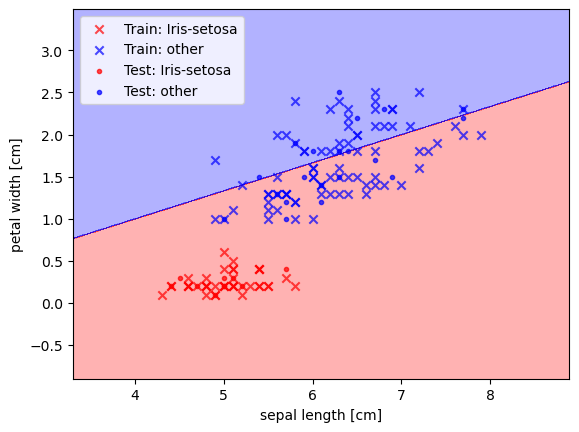

In [14]:
fig, ax = plt.subplots()

plt.contourf(x1_grid, x2_grid, h_grid, cmap=cmap, alpha=.3)

plt.scatter(train_X_minus1[:, 0], train_X_minus1[:, 1], marker='x', color='red', label='Train: Iris-setosa', alpha=.7)
plt.scatter(train_X_plus1[:, 0], train_X_plus1[:, 1], marker='x', color='blue', label='Train: other', alpha=.7)

test_X_minus1 = test_X[test_Y == -1]
test_X_plus1 = test_X[test_Y == +1]
plt.scatter(test_X_minus1[:, 0], test_X_minus1[:, 1], marker='.', color='red', label='Test: Iris-setosa', alpha=.7)
plt.scatter(test_X_plus1[:, 0], test_X_plus1[:, 1], marker='.', color='blue', label='Test: other', alpha=.7)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal width [cm]')
plt.legend()

## Evaluate accuracy

In [15]:
N = len(train_X)
train_errors = np.sum(model(train_X) != train_Y)
print(f'Sample size: {N}')
print(f'Number of correct classifications: {N - train_errors}')
print(f'Number of incorrect classifications: {train_errors}')

Sample size: 120
Number of correct classifications: 70
Number of incorrect classifications: 50


In [16]:
def accuracy(y_pred,y_true):
    return (np.sum(y_pred == y_true)/y_true.size)*100

print(f"Train accuracy: {accuracy(model(train_X),train_Y)}")
print(f"Test accuracy: {accuracy(model(test_X),test_Y)}")

Train accuracy: 58.333333333333336
Test accuracy: 60.0


## Is the Data Linearly Separable?

Yes. Try $w=(0, 1)$ and $b=-0.8$ and observe the accuracy.

In [17]:
w = np.array([0, 1])
b = -0.8
model = LinearBinaryClassification(w, b)

print(f"Train accuracy: {accuracy(model(train_X),train_Y)}")

Train accuracy: 100.0


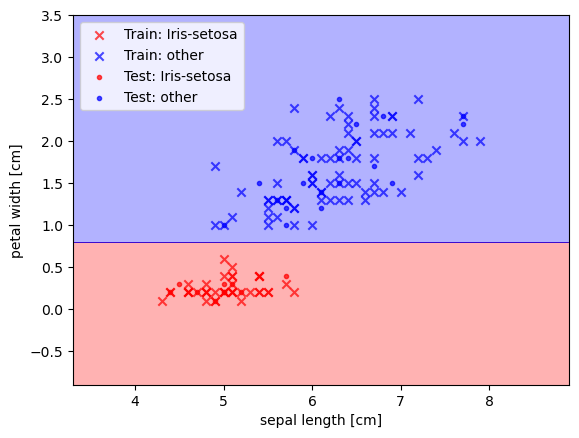

In [18]:
h_grid = model(X_list)

cmap = matplotlib.colors.ListedColormap(['red', 'blue'])
plt.contourf(x1_grid, x2_grid, h_grid, cmap=cmap, alpha=.3)

plt.scatter(train_X_minus1[:, 0], train_X_minus1[:, 1], marker='x', color='red', label='Train: Iris-setosa', alpha=.7)
plt.scatter(train_X_plus1[:, 0], train_X_plus1[:, 1], marker='x', color='blue', label='Train: other', alpha=.7)

plt.scatter(test_X_minus1[:, 0], test_X_minus1[:, 1], marker='.', color='red', label='Test: Iris-setosa', alpha=.7)
plt.scatter(test_X_plus1[:, 0], test_X_plus1[:, 1], marker='.', color='blue', label='Test: other', alpha=.7)

plt.xlabel('sepal length [cm]')
plt.xlim(x1_min, x1_max)
plt.ylabel('petal width [cm]')
plt.ylim(x2_min, x2_max)
plt.legend()

## 🧪 Exercise: Ordinary Least Squares Classifier

Implement an **Ordinary Least Squares (OLS) classifier** as a **child class** of `LinearBinaryClassification`.

Your class should include a method `fit(X, Y)` that computes the parameters of the linear classifier using the theoretical solution of the OLS problem.

Then test your implementation on the Iris dataset.

In [31]:
# Ordinary Least Squares (OLS) classifier

class OLSClassifier(LinearBinaryClassification):
    
        def fit(self, X, Y): 
                X_b = np.column_stack([X, np.ones(X.shape[0])]) # Add bias term to X
           
                w_tilde = np.linalg.lstsq(X_b, Y, rcond=None)[0] # Solve for w_tilde using least squares
        
                self.w = w_tilde[:-1]  # Extract weights
                self.b = w_tilde[-1]   # Extract bias term
                
                return self.w, self.b    


    
model = OLSClassifier(None, None)
model.fit(X, Y)

print(model.w)
print(model.b)

[-0.02943123  1.12622402]
-0.8446573945350682
